[Source](https://docs.nvidia.com/bionemo-framework/1.10/notebooks/MolMIM_GenerativeAI_local_inference_with_examples.html)

In [1]:
# %%capture --no-display --no-stderr cell_output

import os
import itertools
import warnings
import logging
import random

import torch
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from tqdm import tqdm
import numpy as np

from bionemo.utils.hydra import load_model_config
from bionemo.model.molecule.molmim.infer import MolMIMInference

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

logging.basicConfig(level=logging.INFO)
logging.getLogger("nemo_logger").setLevel(logging.ERROR)

/usr/local/lib/python3.10/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
[NeMo W 2024-12-06 11:04:02 nemo_logging:349] /usr/local/lib/python3.10/dist-packages/megatron/core/tensor_parallel/layers.py:257: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
      def forward(
    
[NeMo W 2024-12-06 11:04:02 nemo_logging:349] /usr/local/lib/python3.10/dist-packages/megatron/core/tensor_parallel/layers.py:268: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
      def backward(ctx, grad_output):
    
[NeMo W 2024-12-06 11:04:02 nemo_logging:349] /usr/local/lib/python3.10/dist-packages/megatron/core/tensor_parallel/layers.py:328: FutureWarni

[NeMo I 2024-12-06 11:04:11 megatron_hiddens:110] Registered hidden transform sampled_var_cond_gaussian at bionemo.model.core.hiddens_support.SampledVarGaussianHiddenTransform
[NeMo I 2024-12-06 11:04:11 megatron_hiddens:110] Registered hidden transform interp_var_cond_gaussian at bionemo.model.core.hiddens_support.InterpVarGaussianHiddenTransform


In [2]:
bionemo_home = "/workspace/bionemo"
os.environ['BIONEMO_HOME'] = bionemo_home
os.chdir(bionemo_home)

In [3]:
# !python download_artifacts.py --model_dir ${BIONEMO_HOME}/models --models molmim_70m_24_3

In [4]:
%%capture --no-display --no-stderr cell_output

# Load pre-trained model checkpoints
checkpoint_path = f"{bionemo_home}/models/molecule/molmim/molmim_70m_24_3.nemo"

# checkpoint_path = "/workspace/bionemo/data/models/MolMIM_small_experts_1_max_steps_100.nemo"
# Load starting config for MolMIM inference
cfg = load_model_config(config_name="molmim_infer.yaml", config_path=f"{bionemo_home}/examples/tests/conf/")

# Point YAML configuration file to the location of the desired checkpoints
cfg.model.downstream_task.restore_from_path = checkpoint_path
#cfg.model.encoder.hidden_steps = 2

# Create model object based on desired configuration
model = MolMIMInference(cfg, interactive=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
[W1206 11:04:13.038688400 init.cpp:767] Warning: nvfuser is no longer supported in torch script, use _jit_set_nvfuser_enabled is deprecated and a no-op (function operator())
24-12-06 11:04:13 - PID:81869 - rank:(0, 0, 0, 0) - microbatches.py:39 - INFO - setting number of micro-batches to constant 1


In [5]:
expert_smiles_path = "/workspace/bionemo/data/data_experts_1.csv"
expert_smiles_filename = expert_smiles_path.split("/")[-1]
expert_smiles = pd.read_csv(expert_smiles_path)['smiles'].to_list()

In [6]:
def chem_sample(
        reference_smiles: list[str],
        num_samples: int = 100,
        scaled_radius: float = 1.0,
        sampling_method: str = "beam-search-perturbate",
        **sampler_kwargs
) -> list:
    # PART 1: SAMPLING
    # 1A: Set Sampling Arguments
    default_sampler_kwargs = {"beam_size": 3, "keep_only_best_tokens": True, "return_scores": False}
    sampler_kwargs = {**default_sampler_kwargs, **sampler_kwargs}  # Override defaults with user-provided kwargs

    # 1B: Execute sampling
    population_samples = model.sample(
        seqs=reference_smiles,
        num_samples=num_samples,
        scaled_radius=scaled_radius,
        sampling_method=sampling_method,
        **sampler_kwargs
    )

    # PART 2: FILTERING
    uniq_canonical_smiles = []
    # Loop through each seed molecule
    for smis_samples, original in zip(population_samples, reference_smiles):
        # 2A: Gather unique strings (remove duplicates and starting string)
        smis_samples = set(smis_samples) - {original}

        # 2B: Validate generated molecules
        valid_molecules = []
        for smis in smis_samples:
            mol = Chem.MolFromSmiles(smis)
            if mol:
                valid_molecules.append(Chem.MolToSmiles(mol, True))
        uniq_canonical_smiles.append(valid_molecules)
    return uniq_canonical_smiles  # List (len = seed compounds) of lists (len = generated compounds per seed)

### Sampling methods:
- "greedy-perturbate": Sample the best sequence for each of our perturbed hiddens, using greedy-search (per token)
to find the best result.
- "topkp-perturbate": Sample the best sequence for each of our perturbed hiddens, using `topkp-sampling` to
find the best result.
- "beam-search-perturbate": Sample the best sequence for each of our perturbed hiddens,
using beam-search to find the best result.
 - "beam-search-single-sample": Sample the top num_samples sequences using beam-search (rather than single best) given our
single perturbed hidden.
- "beam-search-perturbate-sample": Sample the top beam_size (default 5) sequences using beam-search
for each of our `num_samples` purturbed hiddens. This will return a `beam_size * num_samples` set of results.

In [7]:
sampling_methods = [
    'greedy-perturbate',
    'topkp-perturbate',
    'beam-search-perturbate',
    'beam-search-single-sample'
    'beam-search-perturbate-sample'
]

## Define sampling arguments

In [8]:
sampling_method: str = "beam-search-perturbate"

In [9]:
model.default_sampling_kwargs[sampling_method]

{'scaled_radius': 1,
 'seqs': [],
 'beam_size': 5,
 'keep_only_best_tokens': True,
 'beam_alpha': 0,
 'hiddens': None,
 'enc_masks': None}

In [10]:
# define any arguments here except for 'seqs', which are defined later
kwargs = {
    'beam_size': 10,
    'beam_alpha': 0.3
}
num_samples: int = 100
scaled_radius: float = 1.0

In [11]:
# gen_smis_lst = []
# for sml in tqdm(expert_smiles, total=len(expert_smiles)):
#     gen_smis = chem_sample([sml], num_samples=num_samples, scaled_radius=scaled_radius, **kwargs)
#     gen_smis_lst.append(gen_smis[0])

In [12]:
# divide the seed smiles into n chunks and generate for each chunk
import numpy as np
gen_smis_lst = []
# n = 1 # CUDA OOM
n = 2
for chunk in np.array_split(expert_smiles, n):
    gen_smis = chem_sample(chunk, num_samples=num_samples, scaled_radius=scaled_radius, **kwargs)
    gen_smis_lst.extend(gen_smis)

In [13]:
gen_smis_lst

[['Cn1c(SCC2=CC(=O)n3nccc3C2)nc2cccc(Cl)c21',
  'Cc1sc(NC2[C@H]3CCC[C@H]2CS(=O)(=O)C3)c(C(=O)O)c1C',
  'Cn1c(C=C2[C@H]3CC[C@H]2CC(N)C3)cnc1CN',
  'C[C@@H]1CCC[C@H](NC(=O)/C=C\\COc2ccccc2)C1',
  'C#CC(C=C)N1CC=C[C@@H]1C(=O)NCCC',
  'CC(C)(CCN1CCC(Cn2cncn2)CC1)NC(=O)OC(C)(C)C',
  'C#CCSCCCN1CCC=C[C@]1(N)CO',
  'Cn1c(C(=O)NCCOC2CCNCC2)ccc1-c1ccccc1',
  'CSCC(=O)N1CCC(CO)(NCC[C@H](C)F)CC1',
  'C[C@H]1C(C(=O)NCC2=CC(=NO)CCC2)[C@@H]1C',
  'COc1ncccc1/C=C1/CCN=C1C',
  'C#CCOc1ccc(CNC2CC(N(C)C(=O)OC(C)(C)C)C2)cc1',
  'Cc1nc(CN2C[C@H](C(=O)O)C[C@@H](S(C)(=O)=O)C2)ccc1Br',
  'C[C@H]1C(C=CBr)=CC=CN1C(=O)OC(C)(C)C',
  'Cn1c(C=C2CCC2=O)cc2cc(C(F)(F)F)ccc21',
  'CCOC(=O)[C@@]1(CC2CC3(C2)CC(C)(C)C3)C=CCN1C(=O)OC(C)(C)C',
  'Cn1c(C=C2[C@H]3CCCC[C@@H]3CN2C(=O)OC(C)(C)C)nnc1C1CC1',
  'C#CC(CC)(CC)NC(=O)c1ccc(C)c(Cl)c1F',
  'C#CC(C#N)=c1sc(=Cc2[nH]c(C)nc2C)c(=O)n1CC(C)C',
  'CCCC(=O)N1CCCC[C@H]1C1CCN(C(=O)CC2(C)CN(C(=O)OC(C)(C)C)C2)CC1',
  'Cc1nn(CC2N=C=CC=C2Br)c2ccccc12',
  'CO[C@@H]1CC=C2C=CC=C2C1=Nc1c

In [14]:
flattened = list(itertools.chain.from_iterable(gen_smis_lst))
if len(flattened) == 0:
    raise ValueError("No valid molecules generated :( Please try again.")
len(flattened)

2024

In [15]:
def format_kwargs(kwargs: dict) -> str:
    return "_".join([f"{k}_{v}" for k, v in kwargs.items()])

In [16]:
fine_tuned_str = "100_steps"
# save to .csv
pd.DataFrame(
    data={"SMILES": flattened}
).to_csv(f"data/outputs/bionemo_molmim_{expert_smiles_filename}_{fine_tuned_str}_num_samples_{num_samples}_sampling_method_{sampling_method}_scaled_radius_{scaled_radius}_{format_kwargs(kwargs)}.csv", index=False)

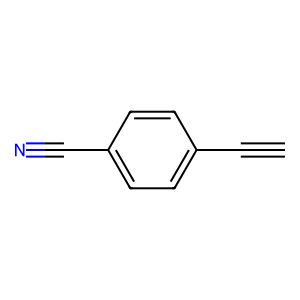

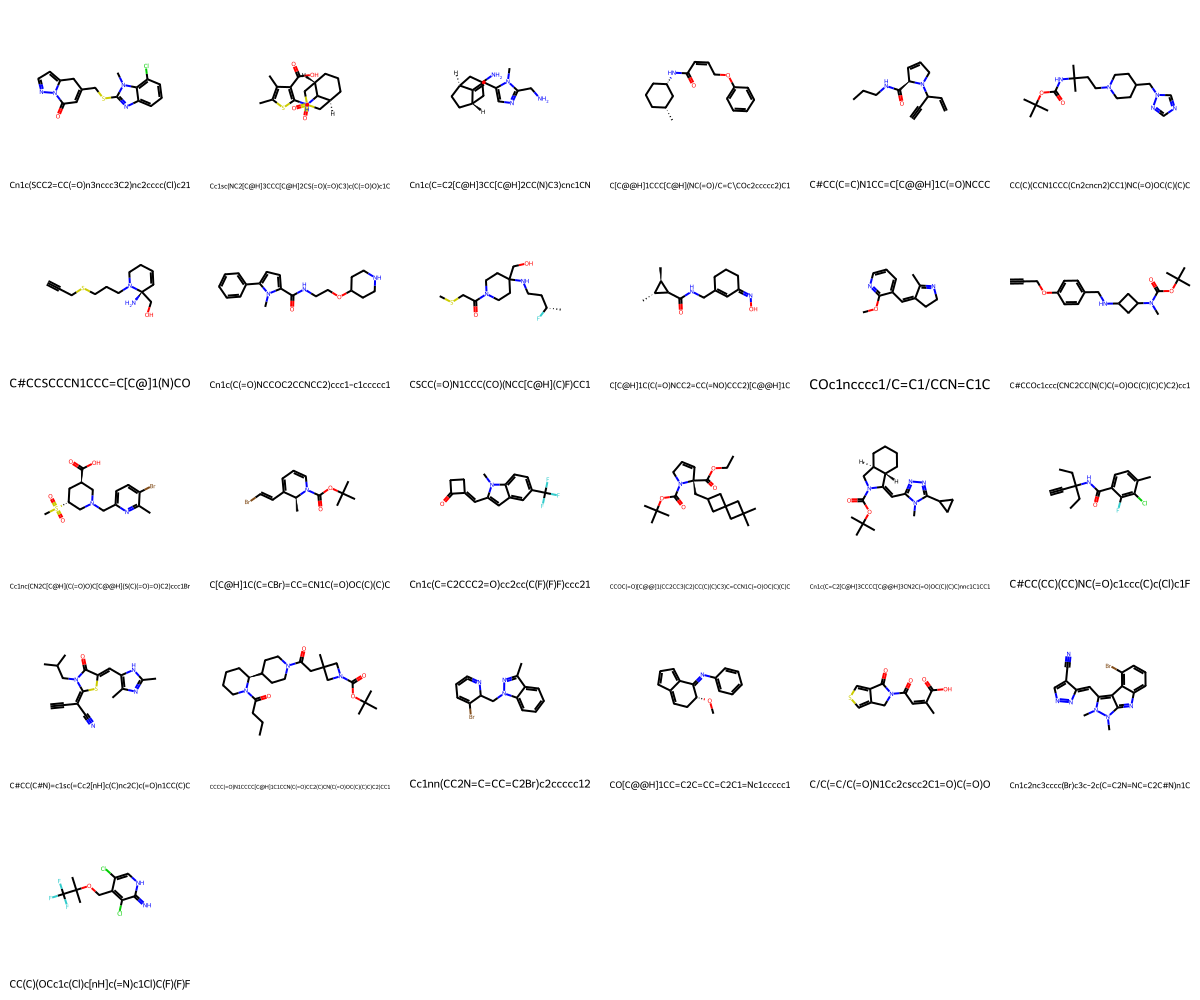

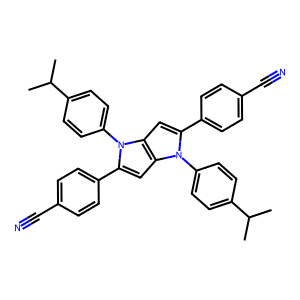

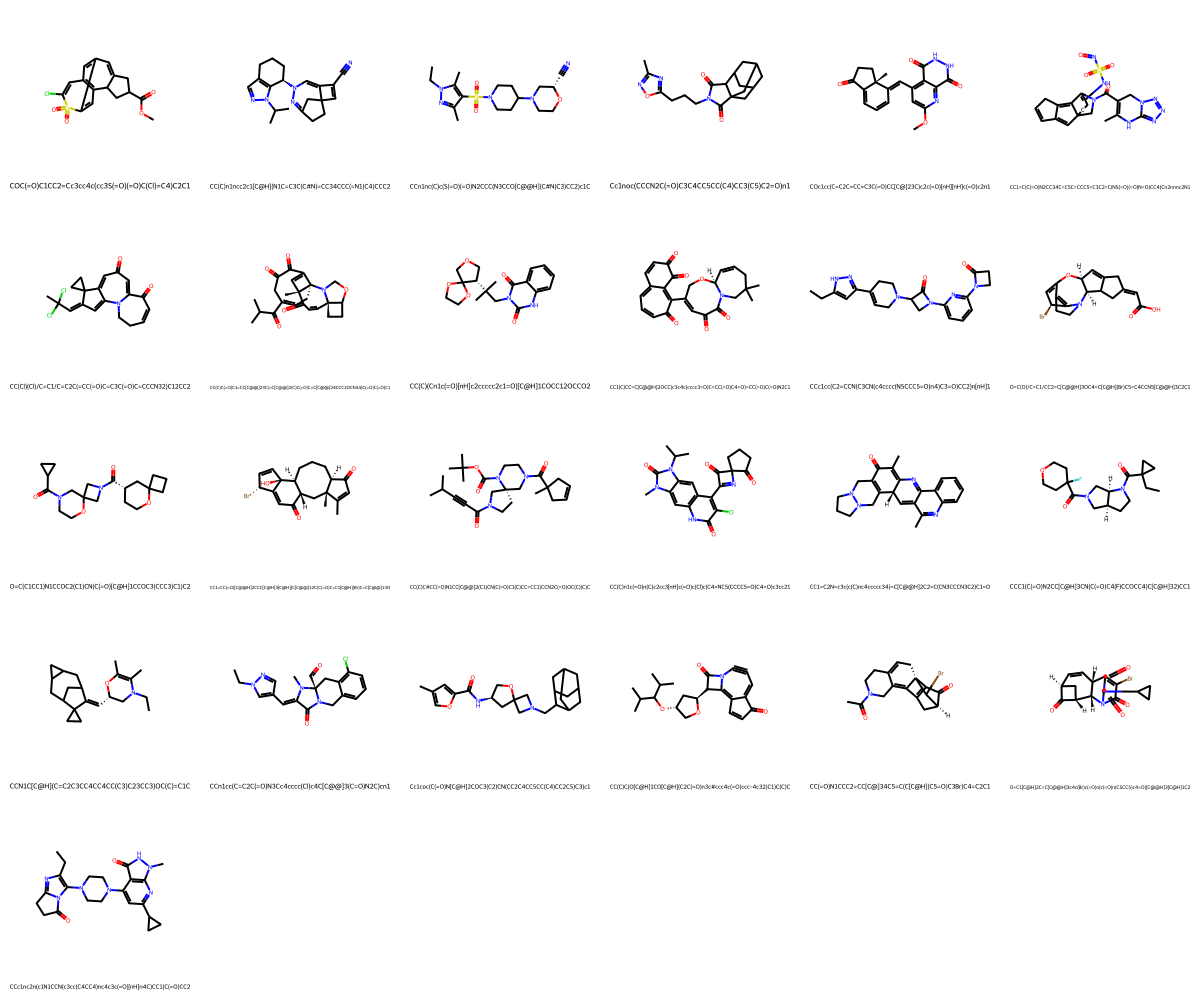

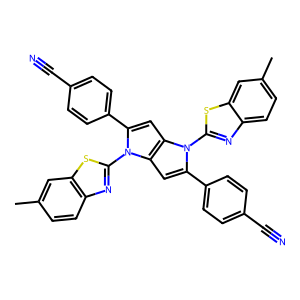

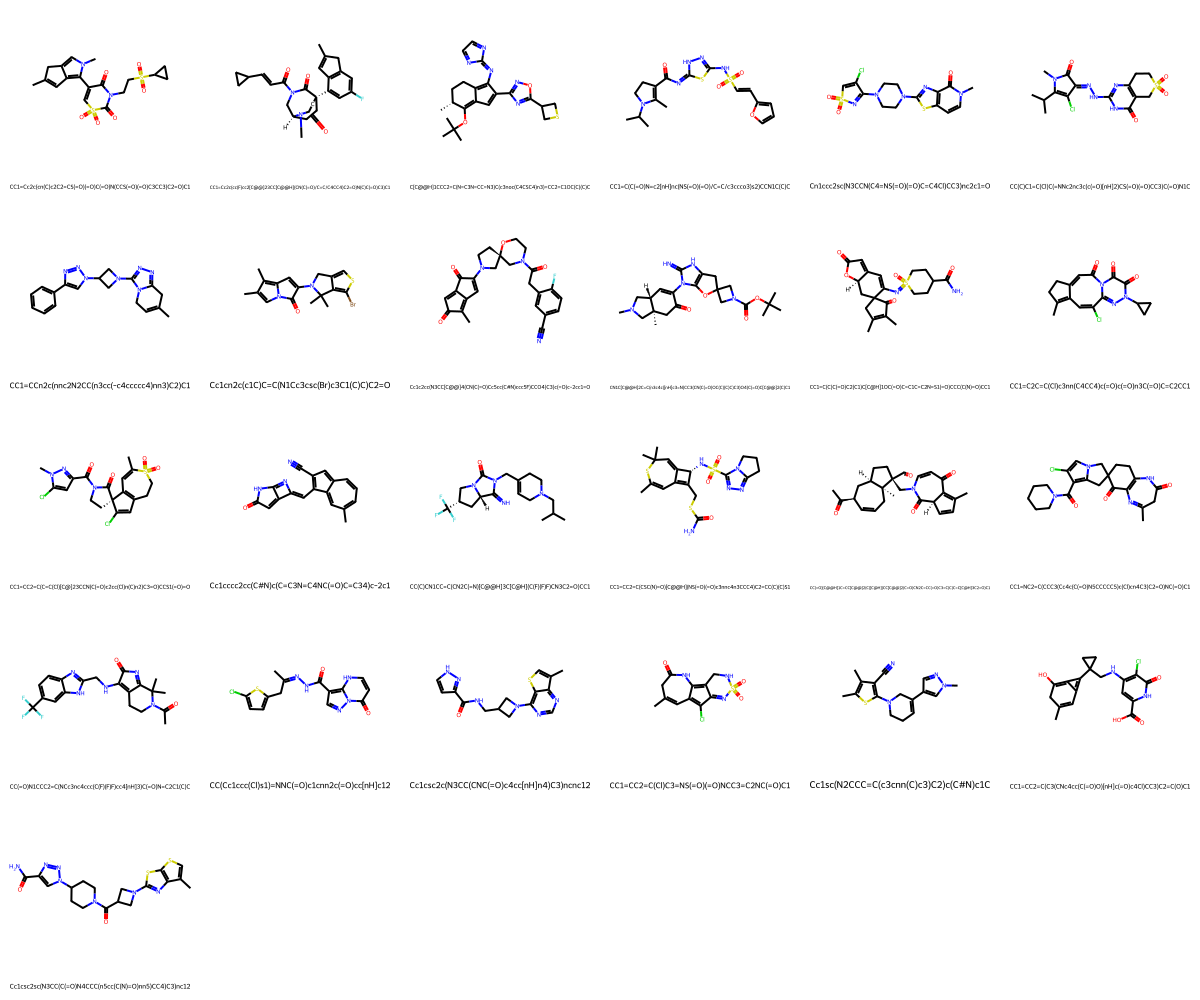

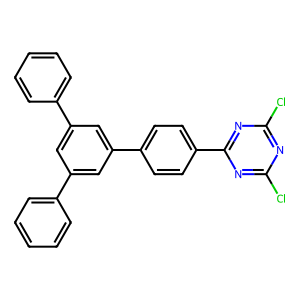

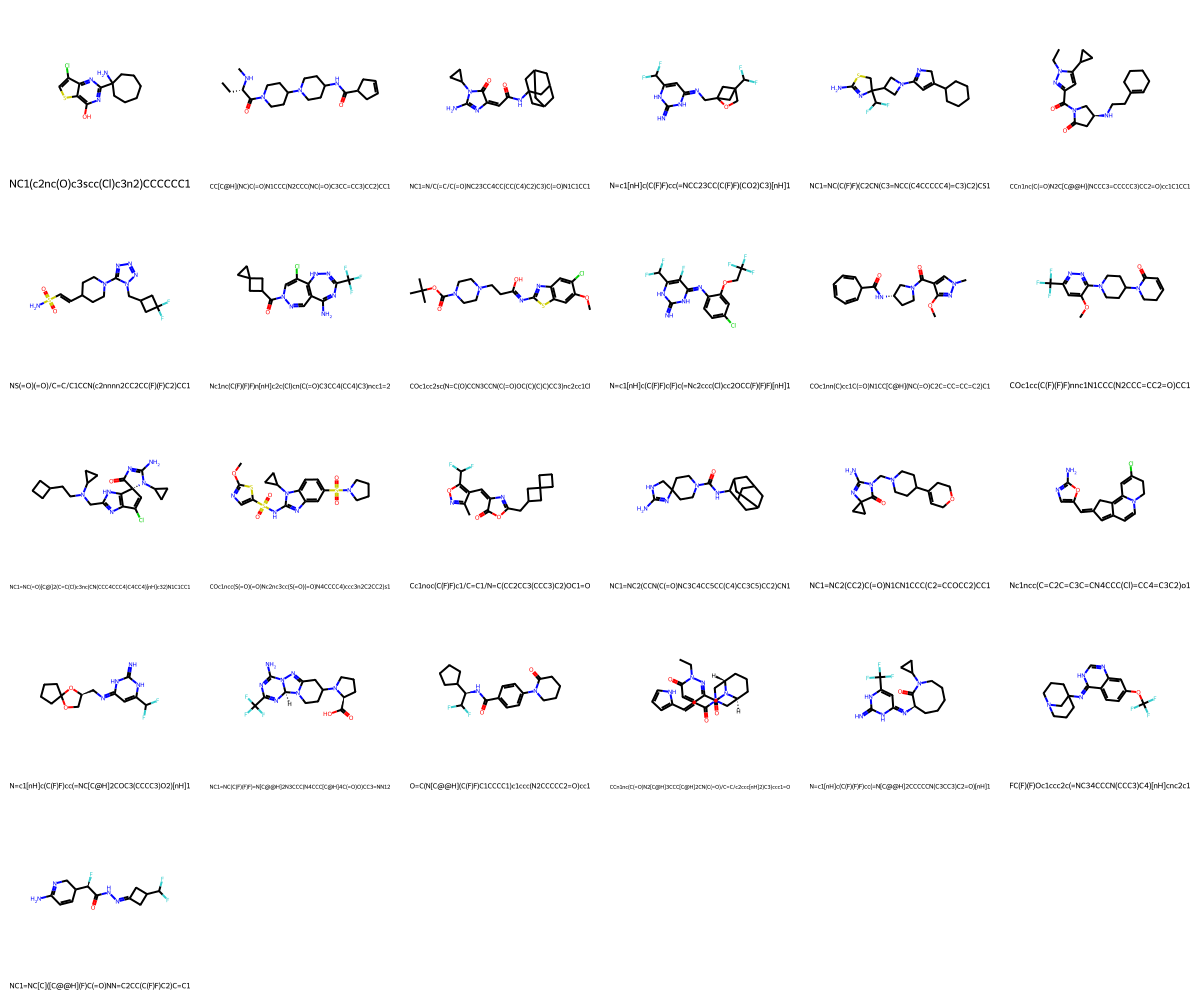

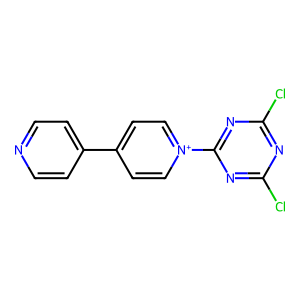

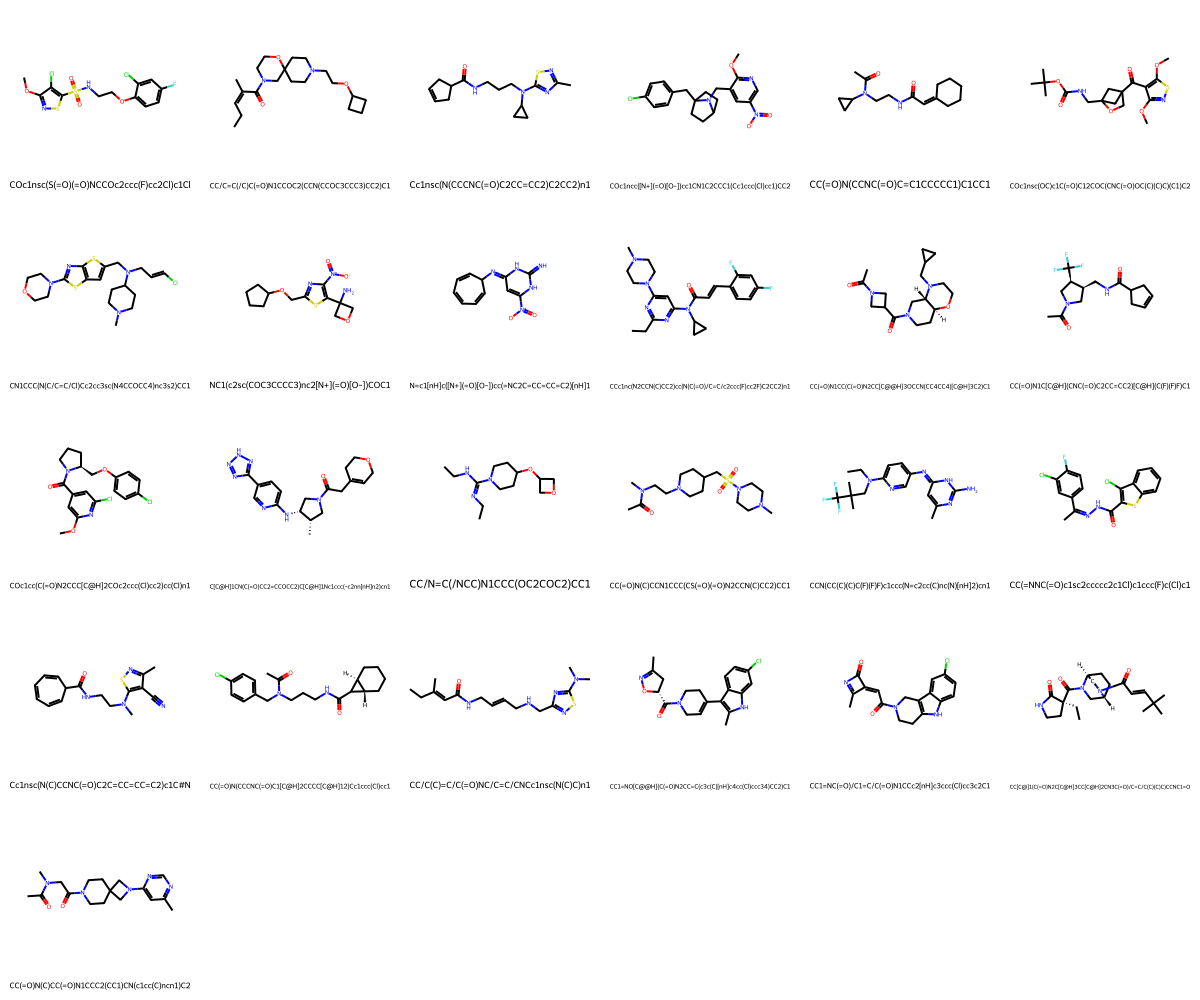

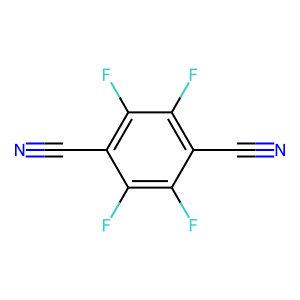

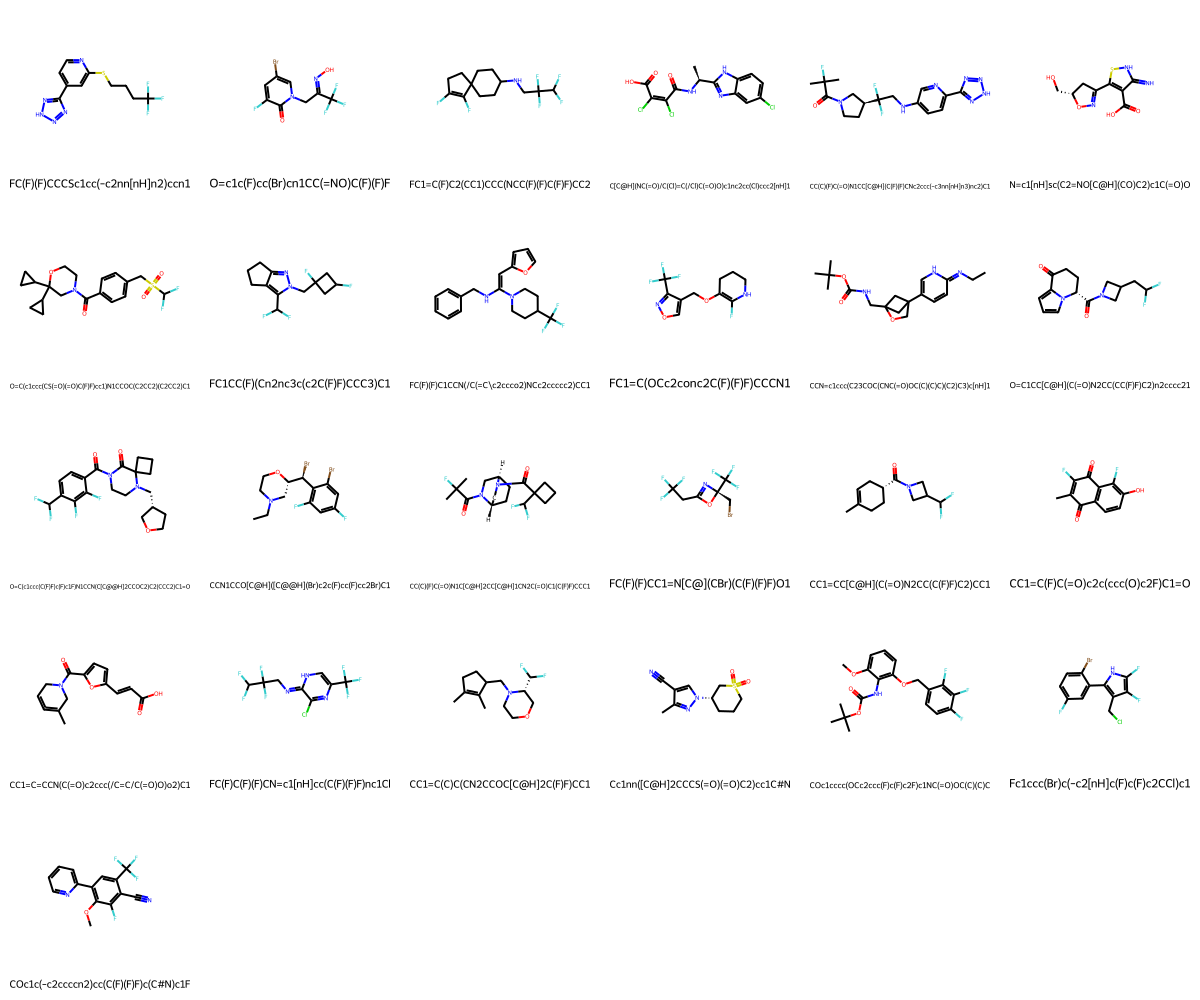

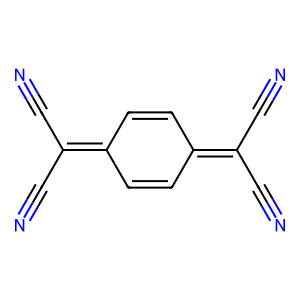

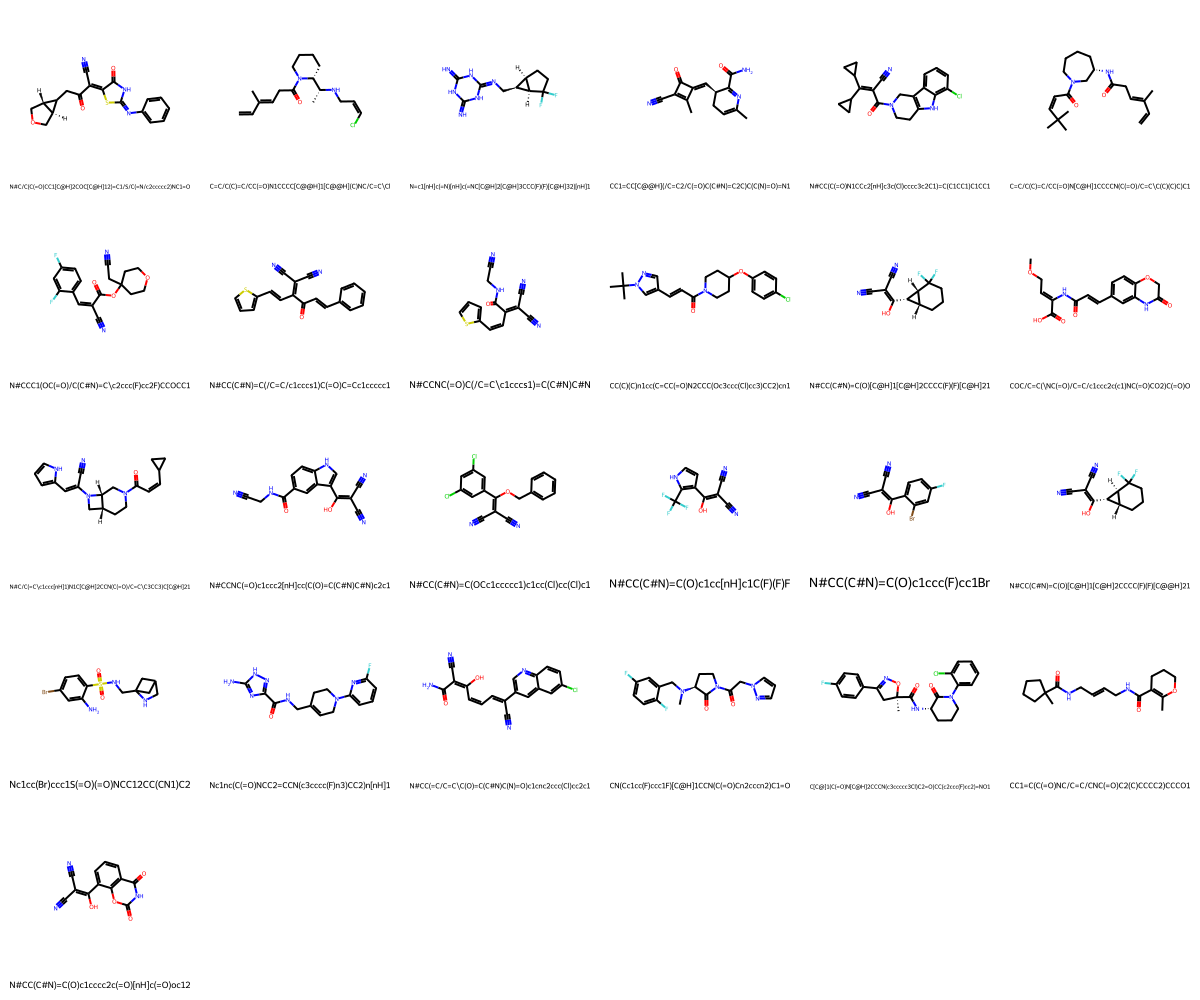

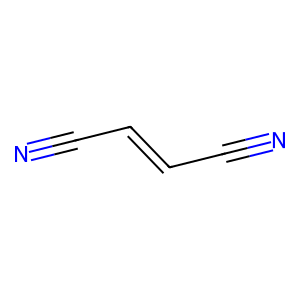

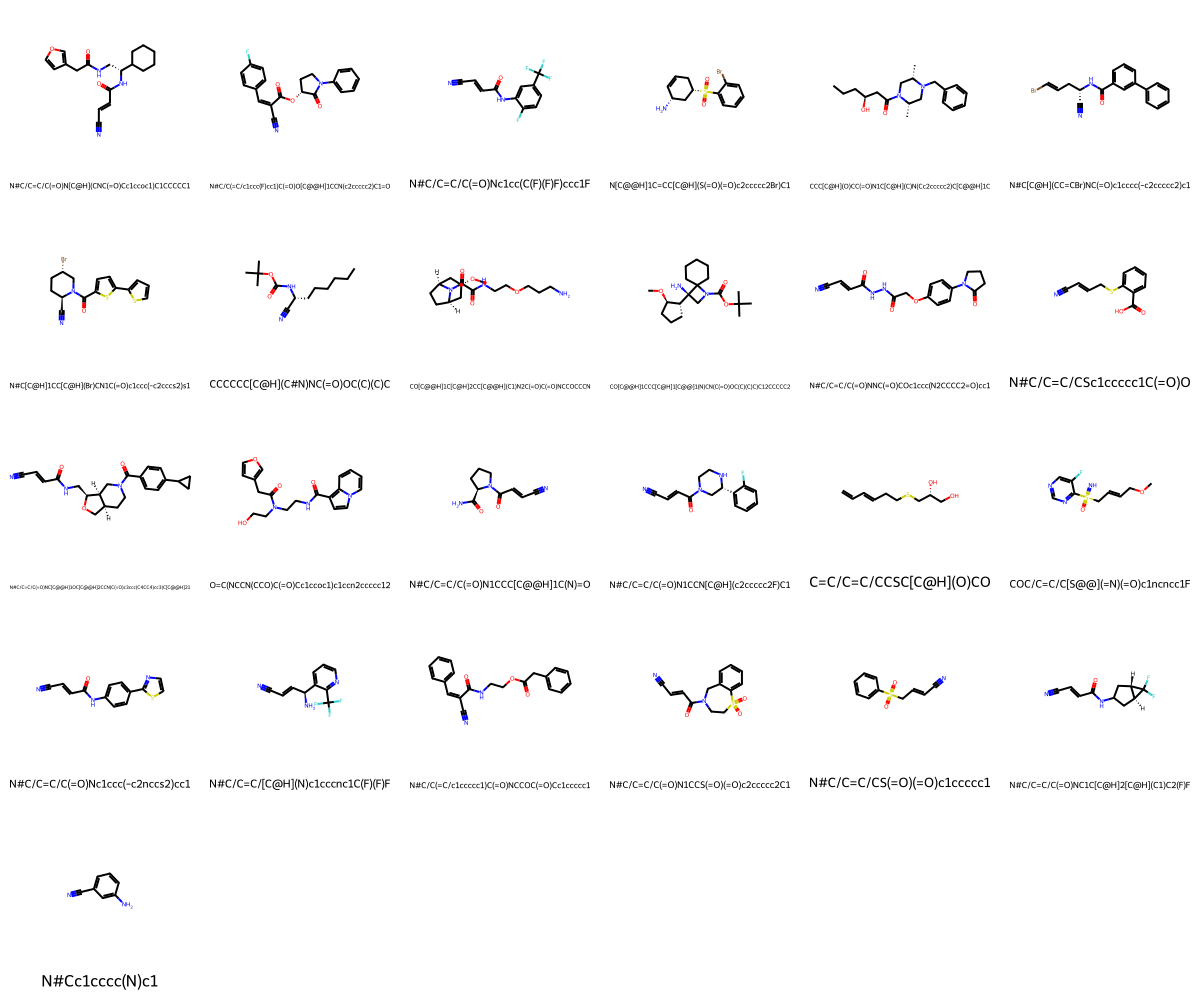

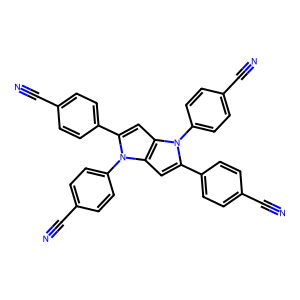

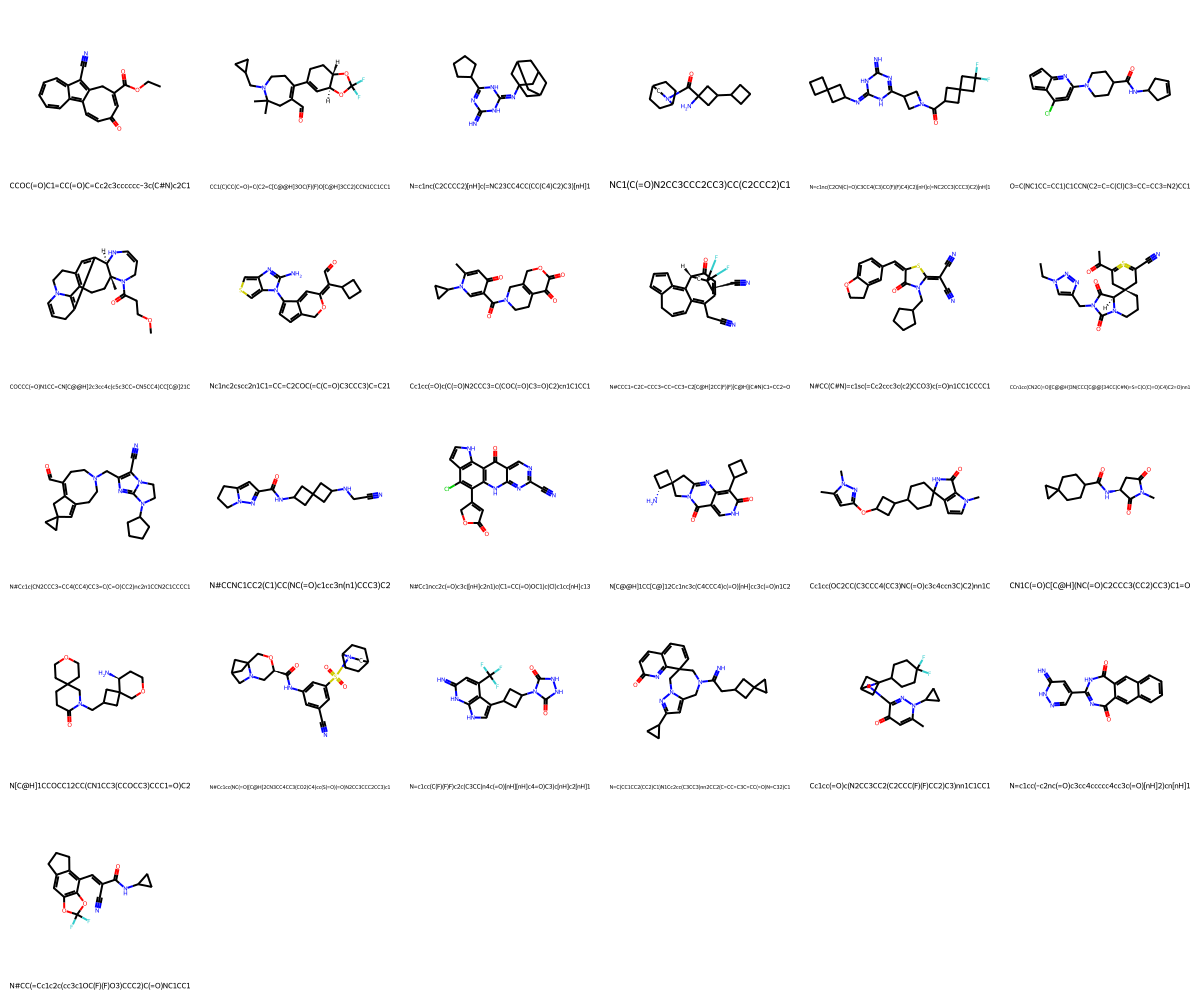

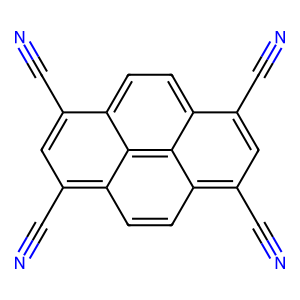

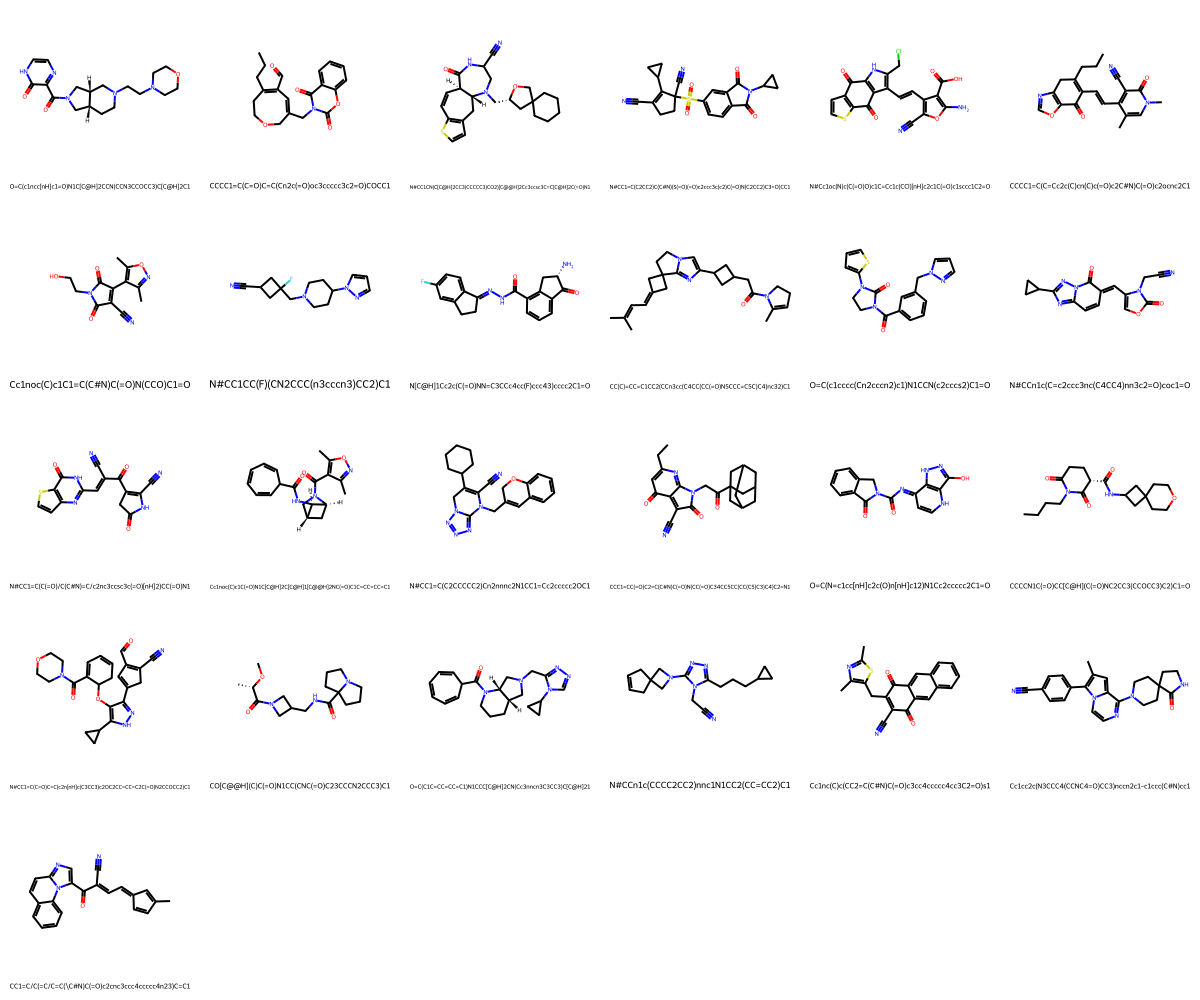

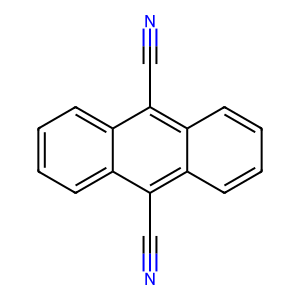

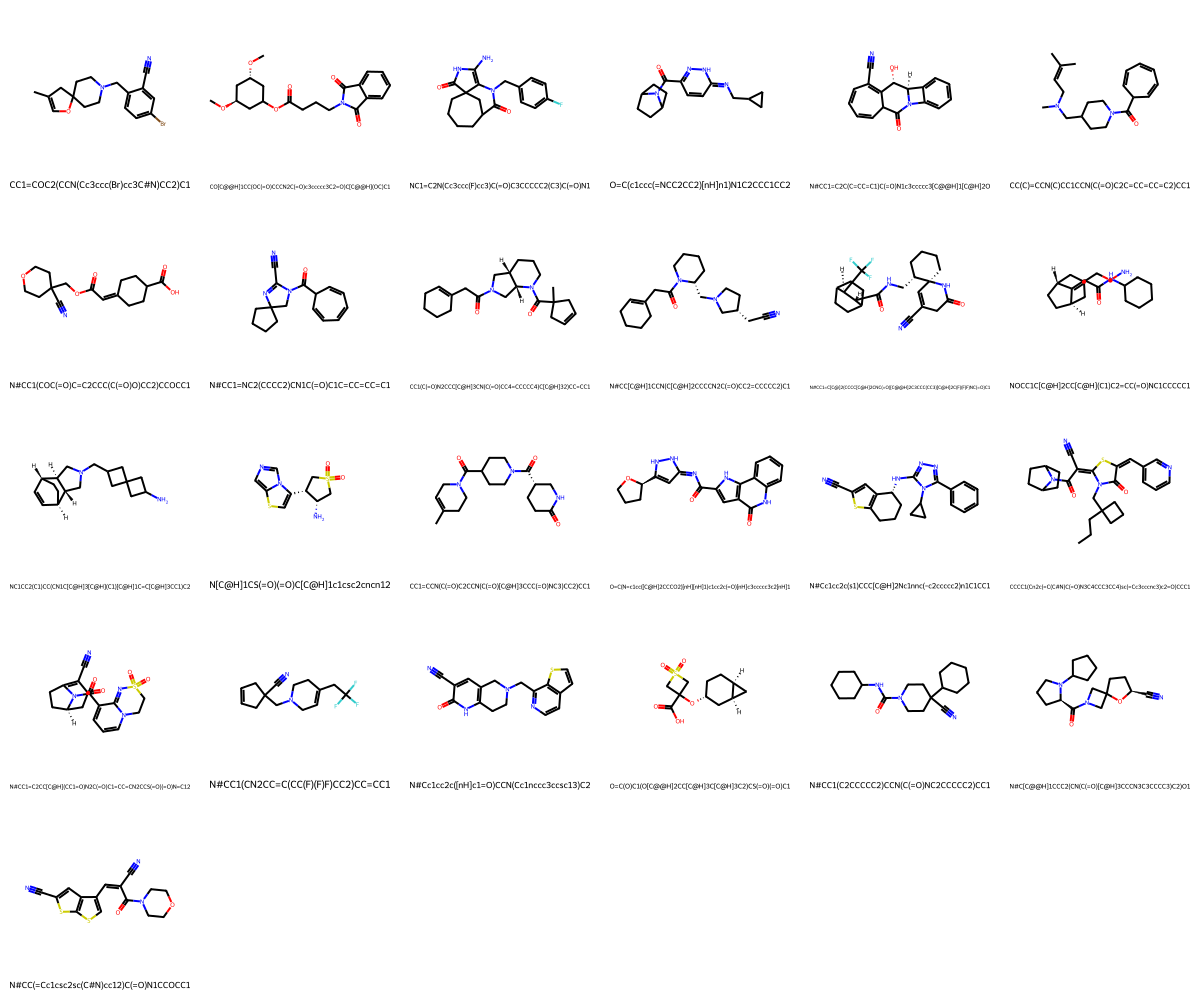

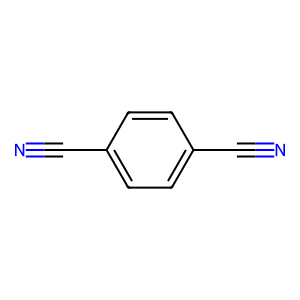

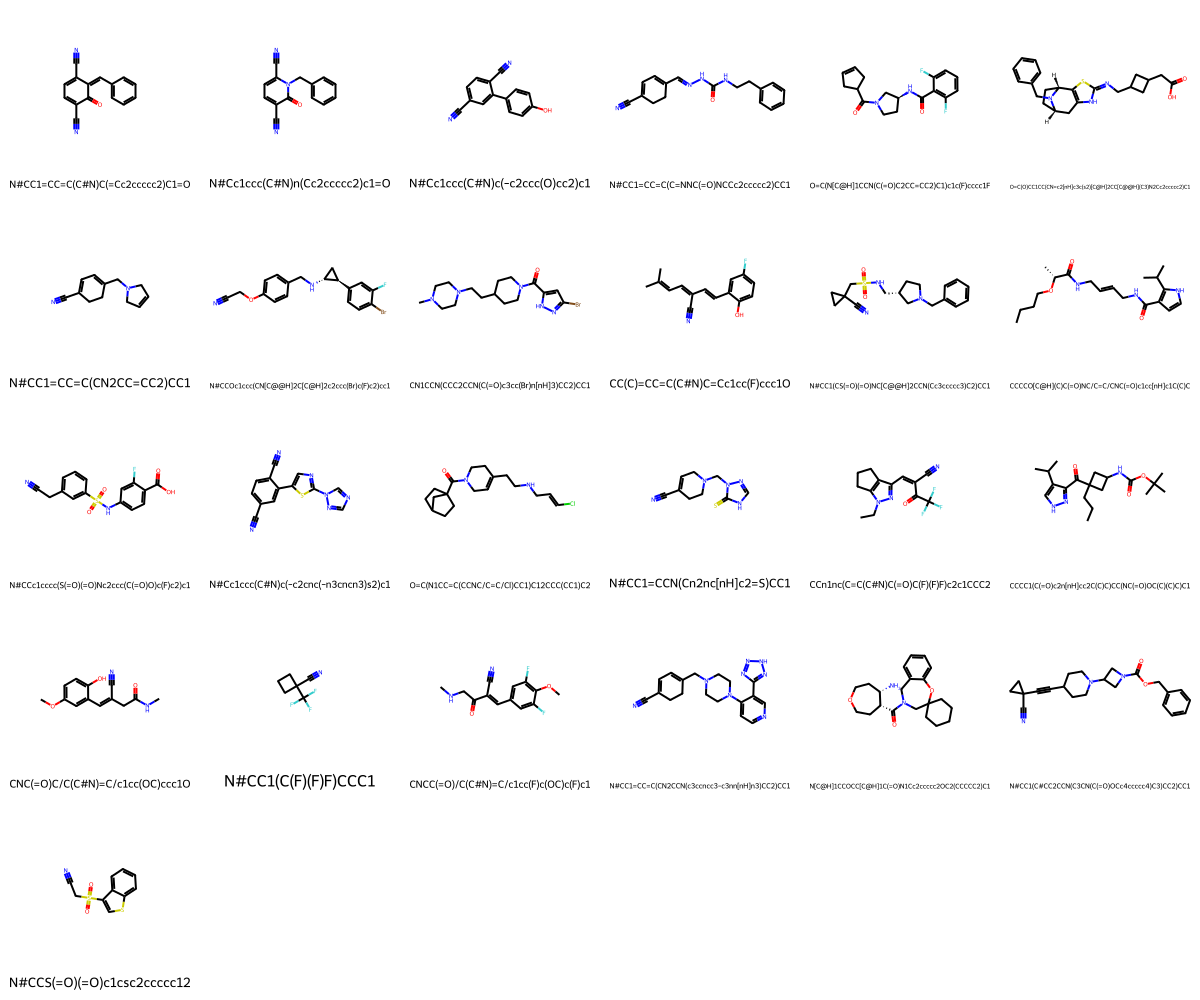

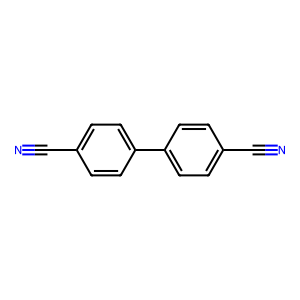

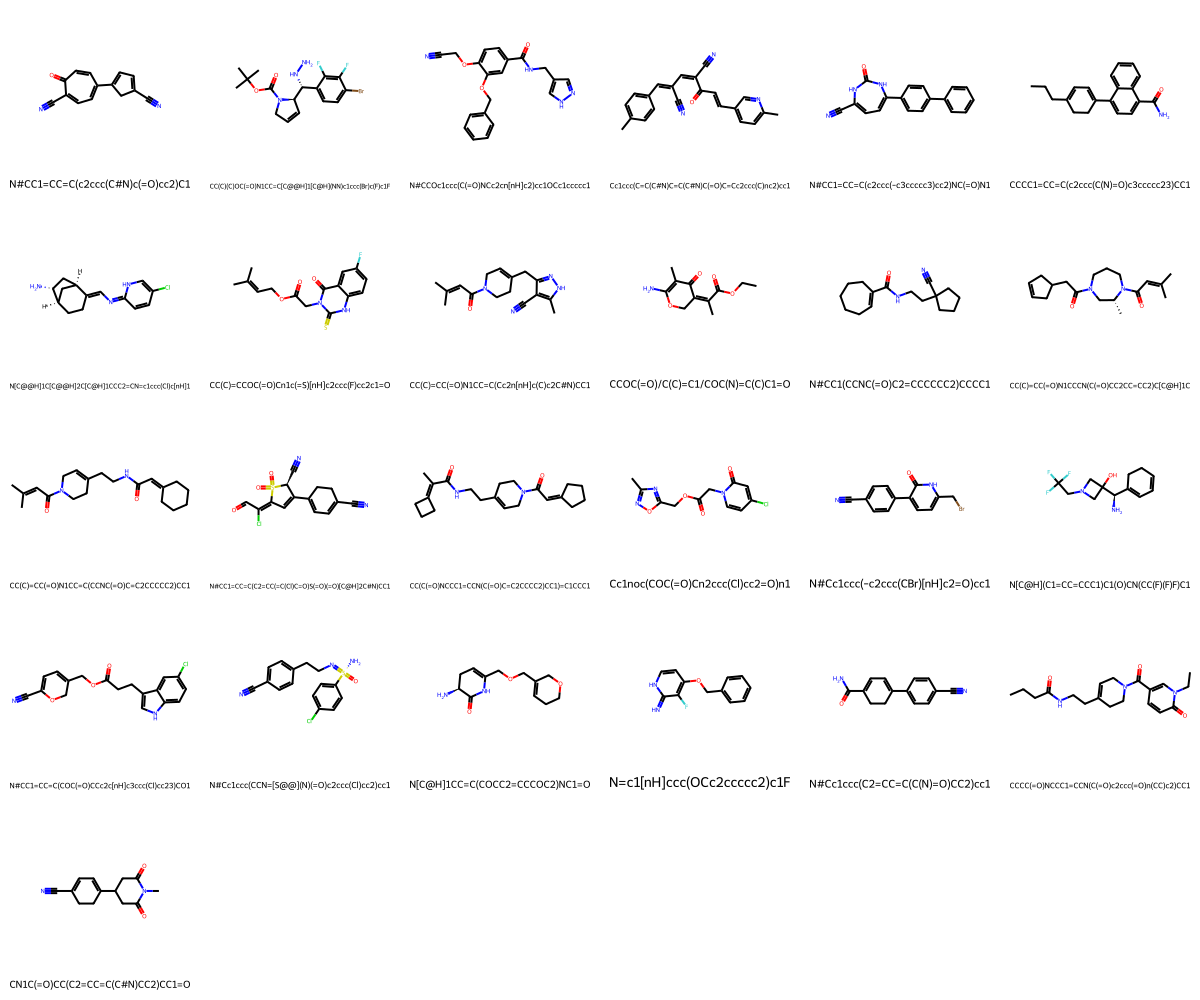

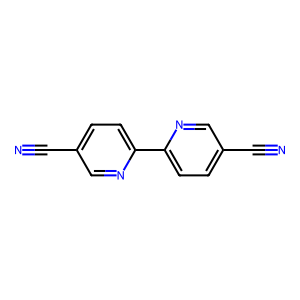

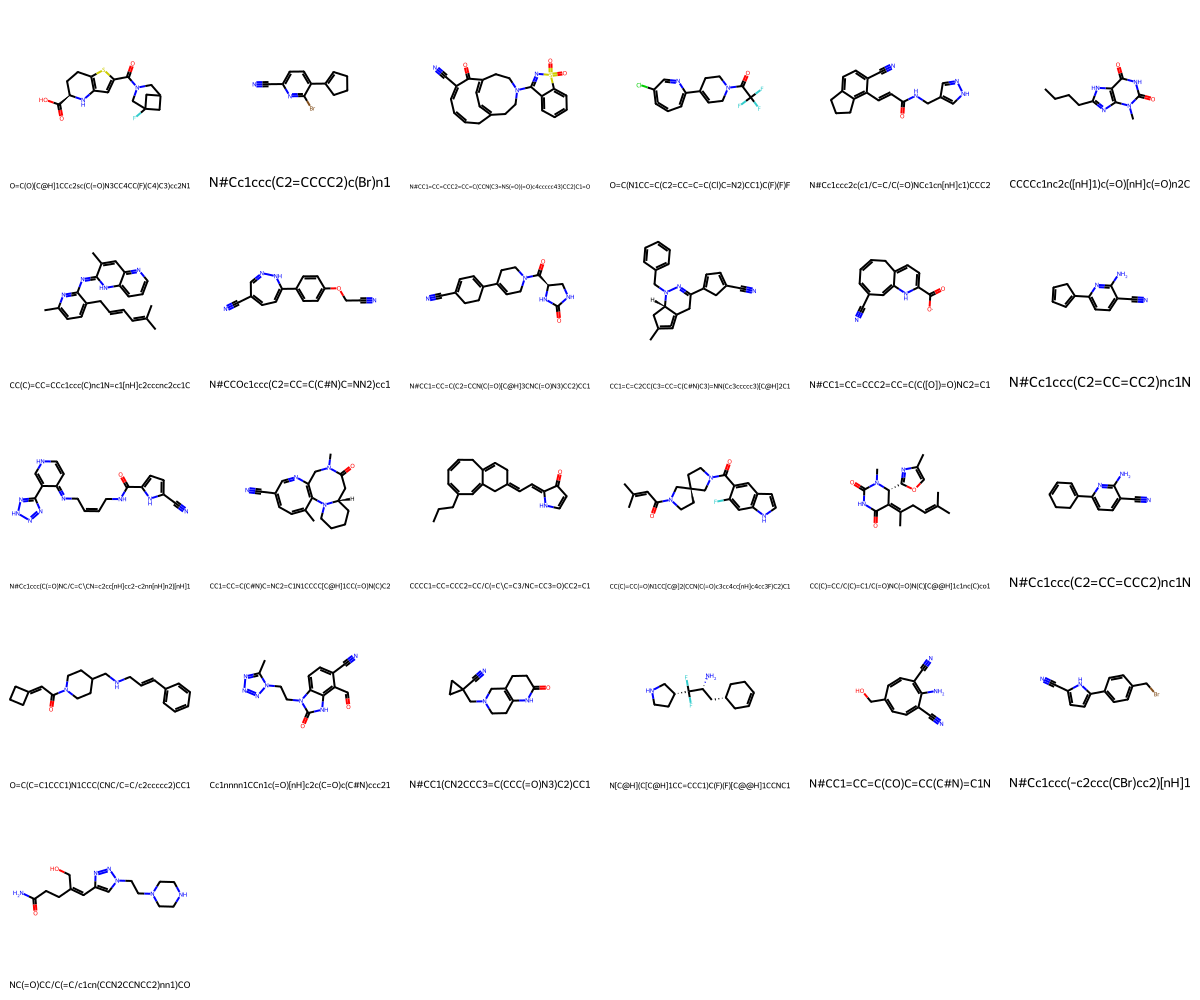

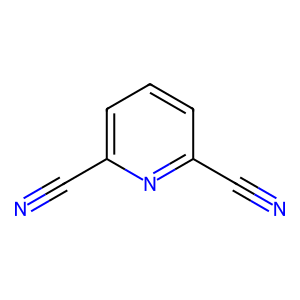

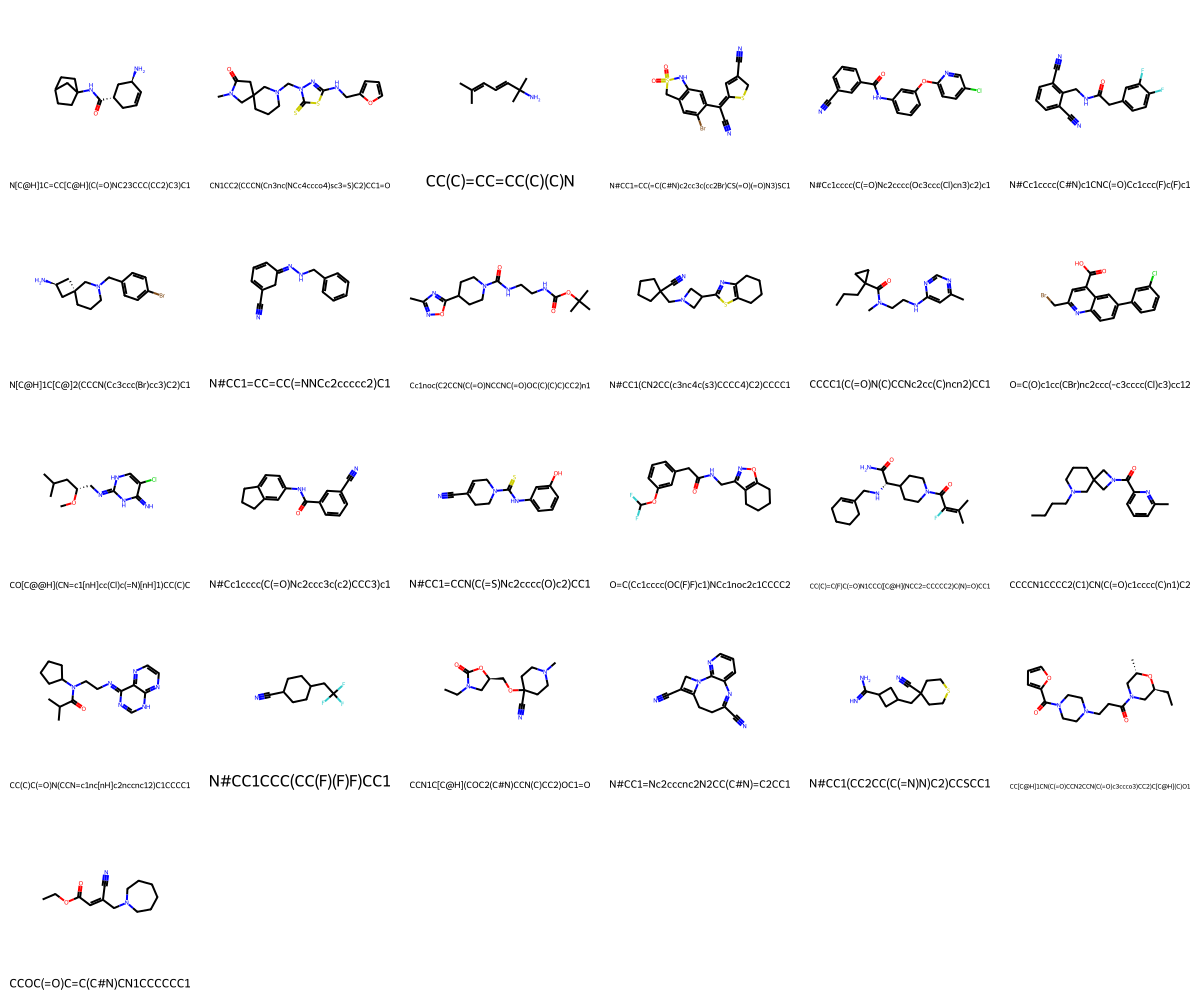

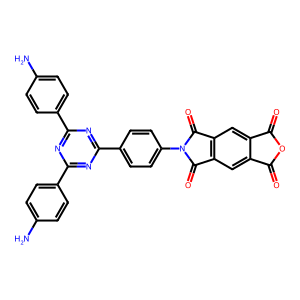

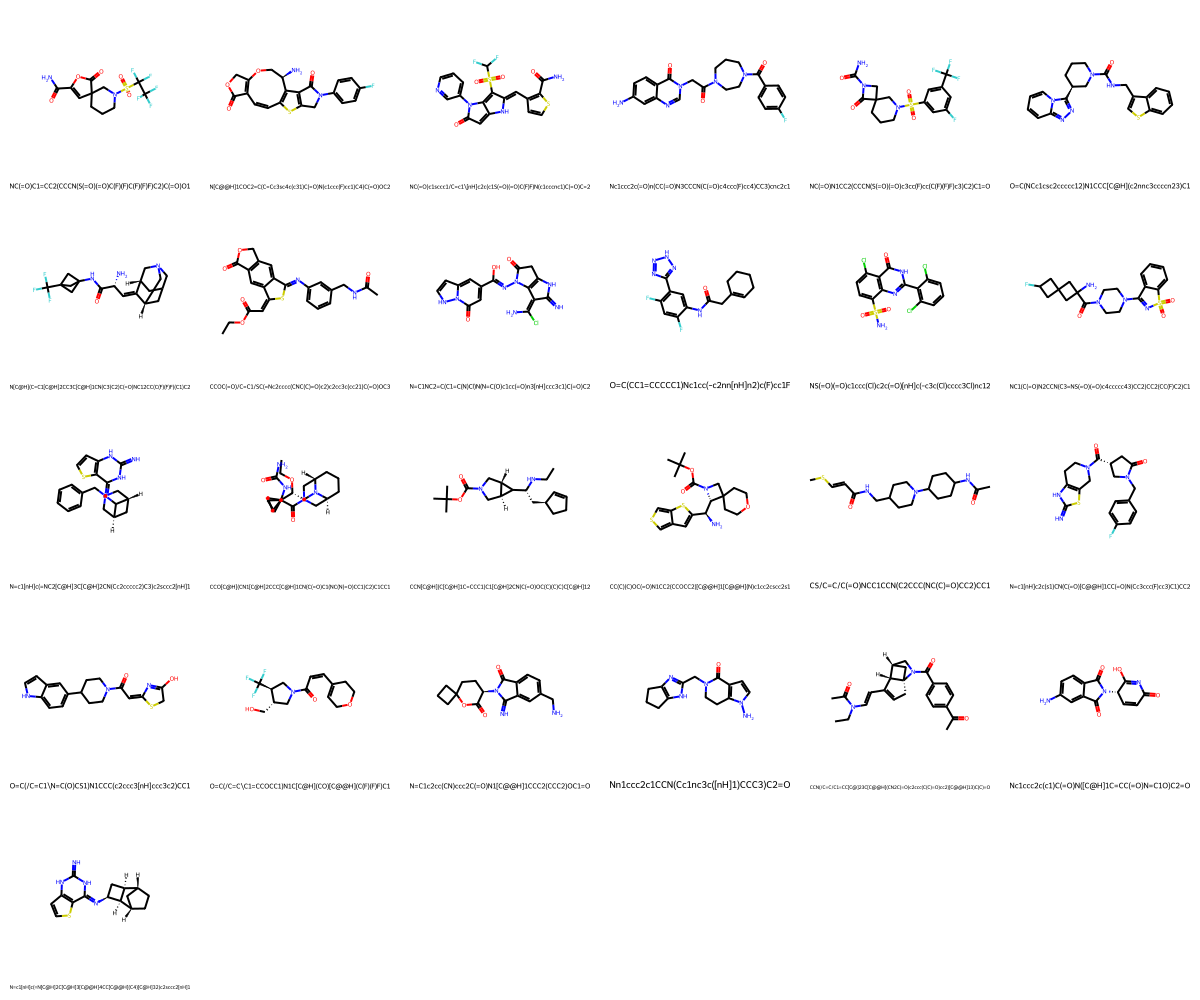

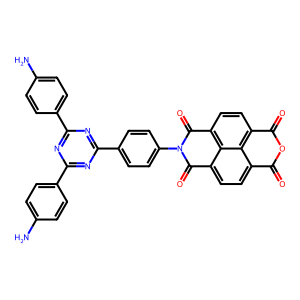

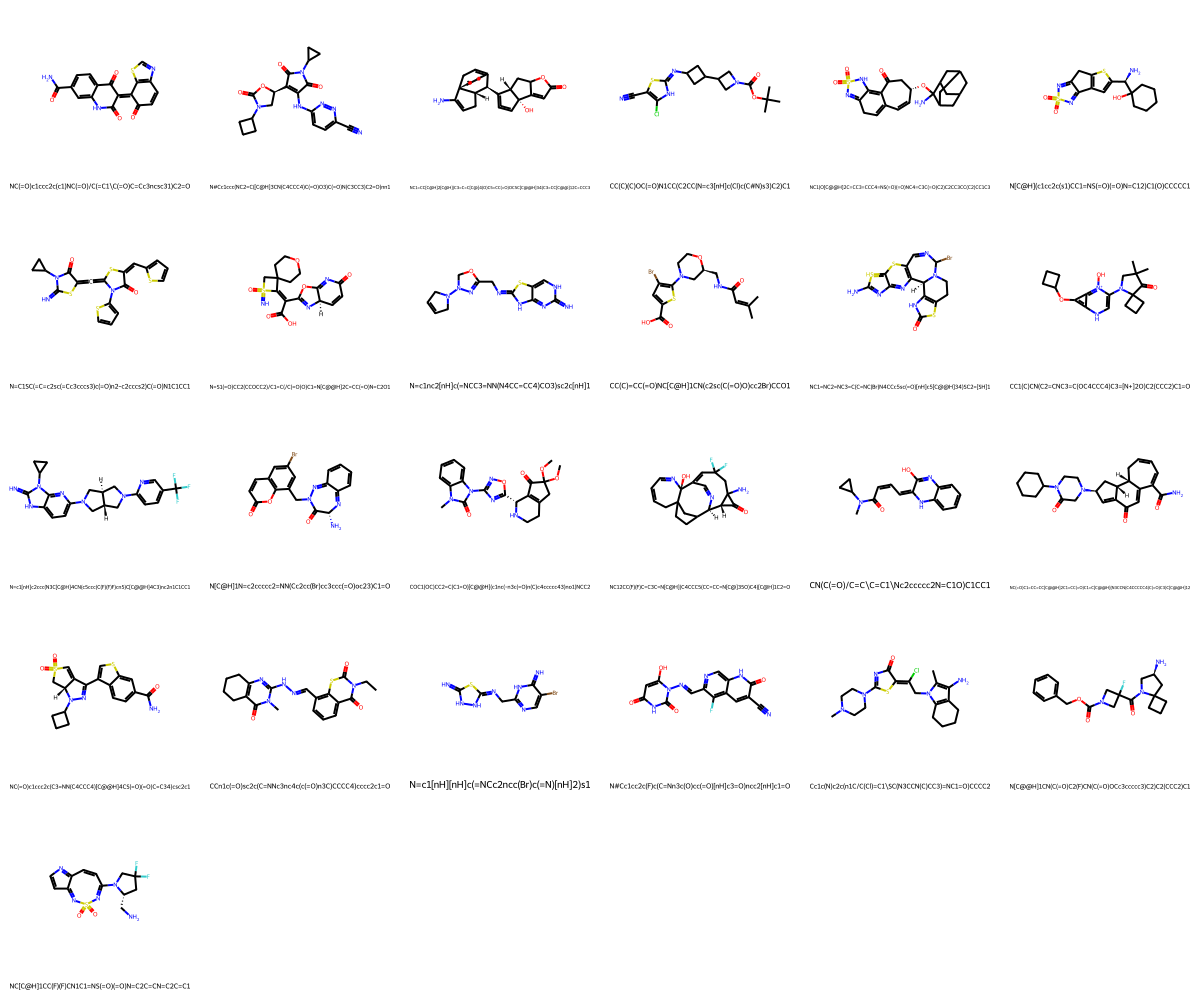

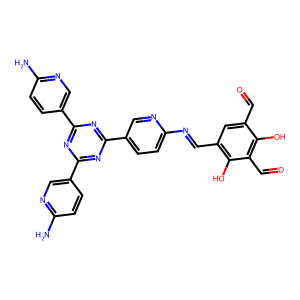

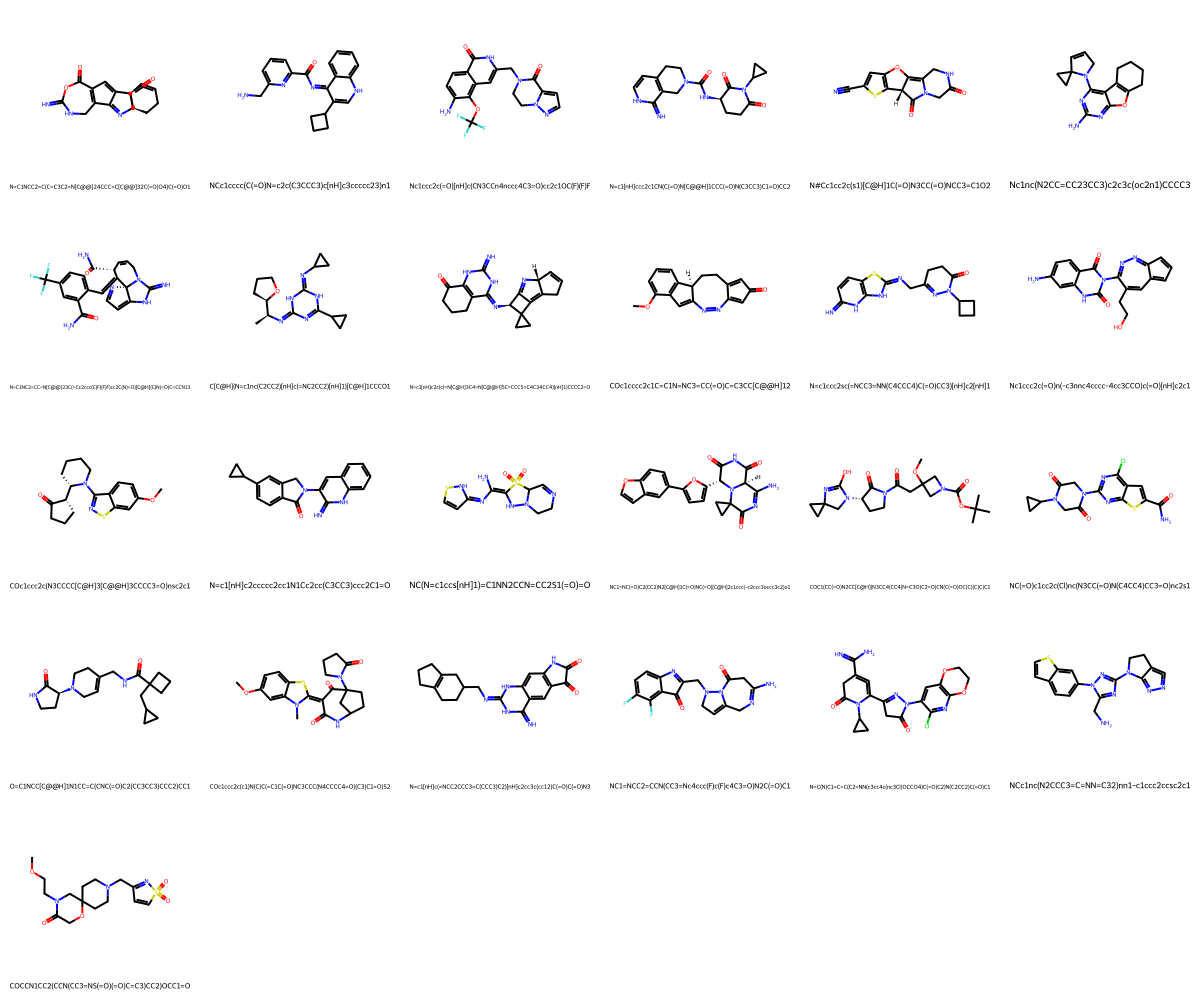

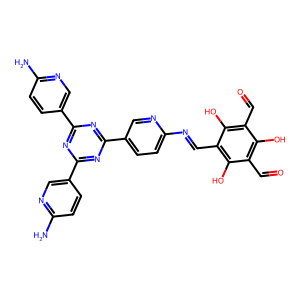

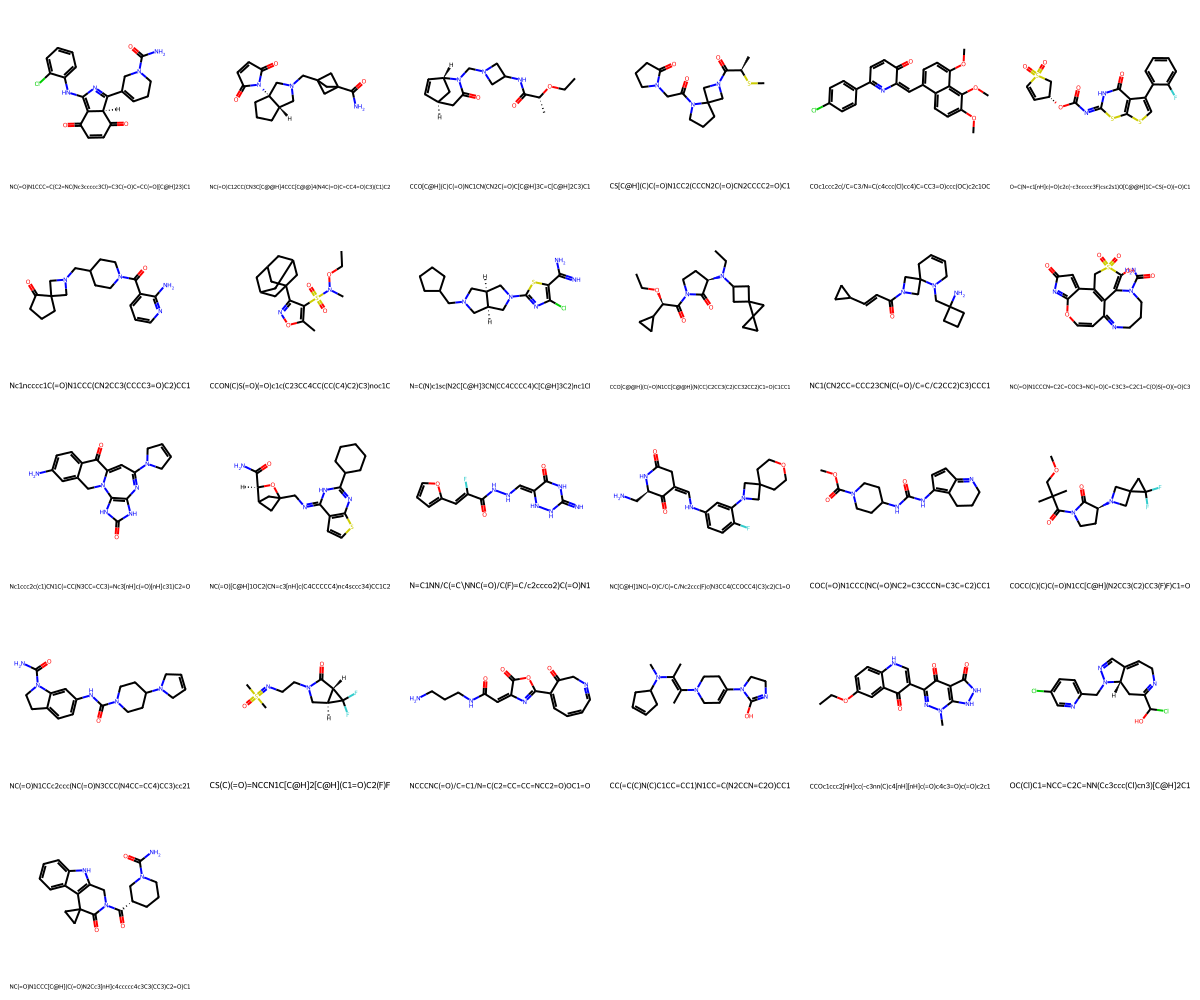

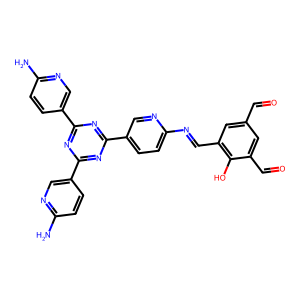

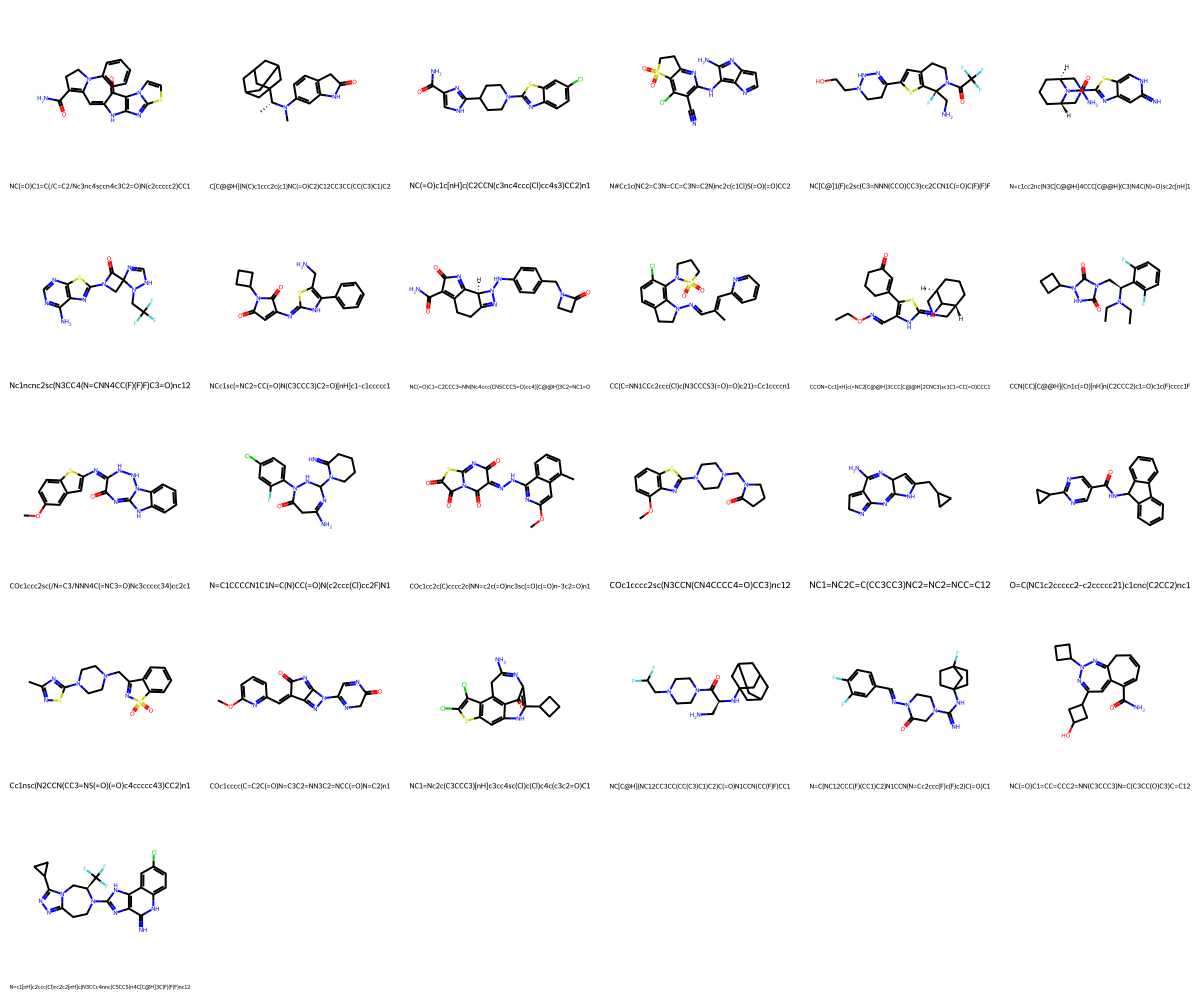

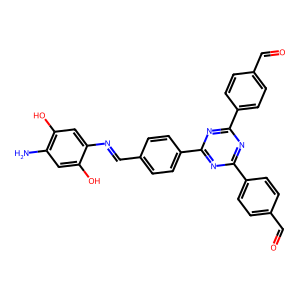

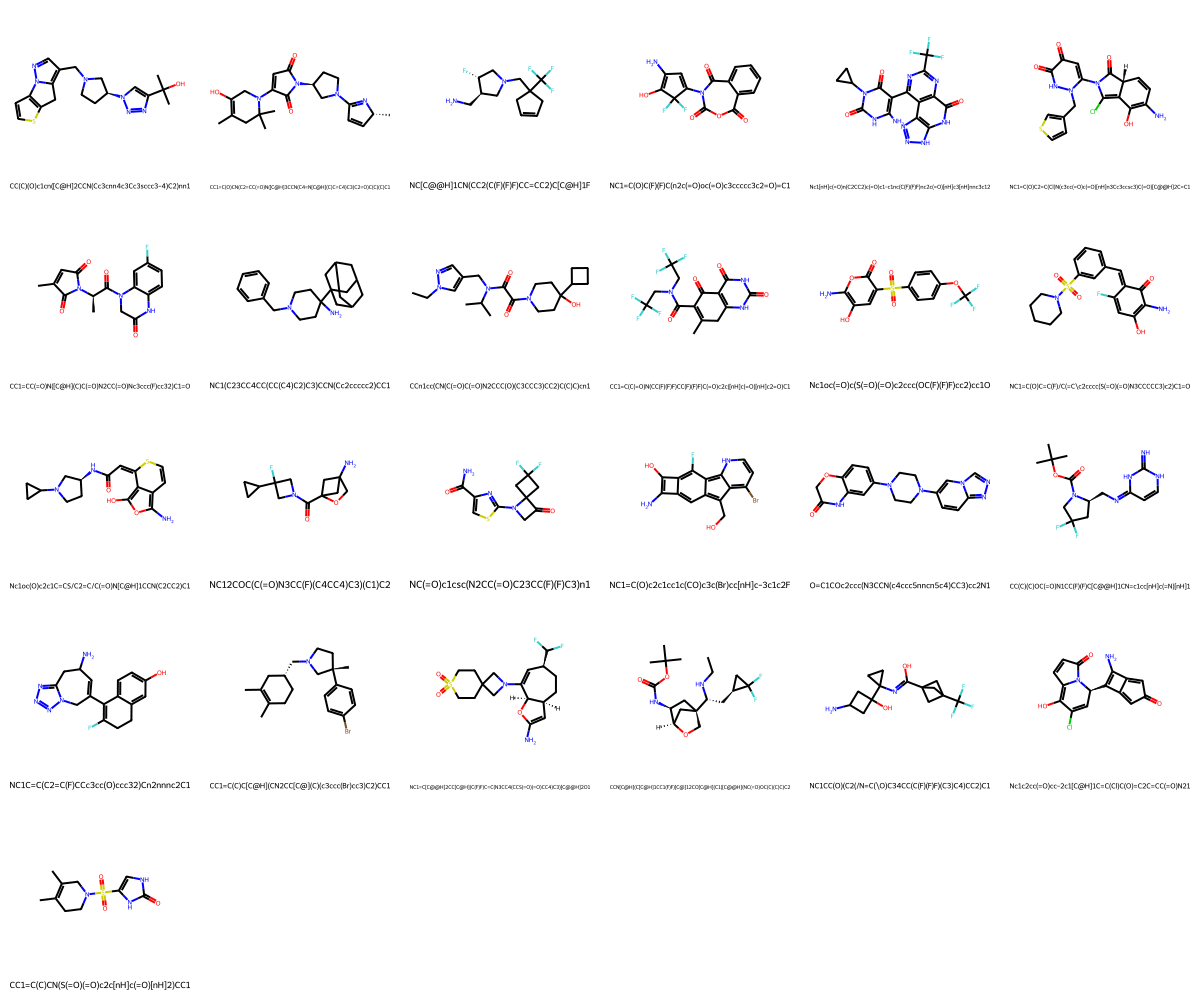

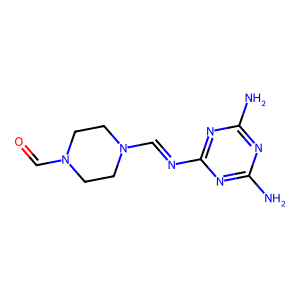

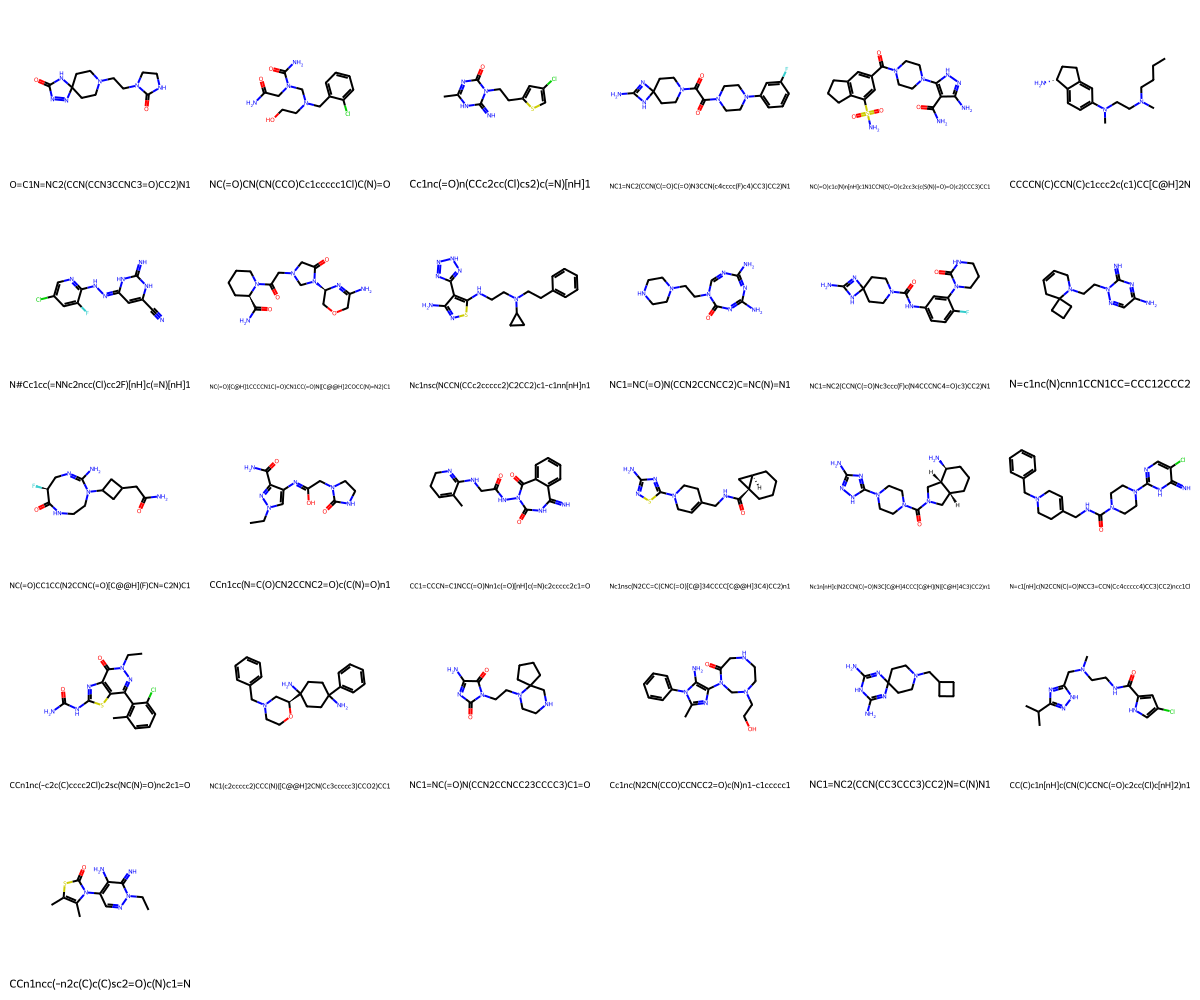

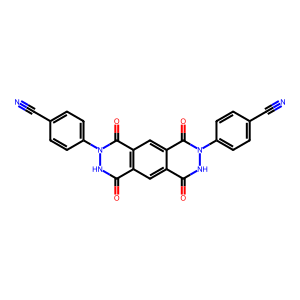

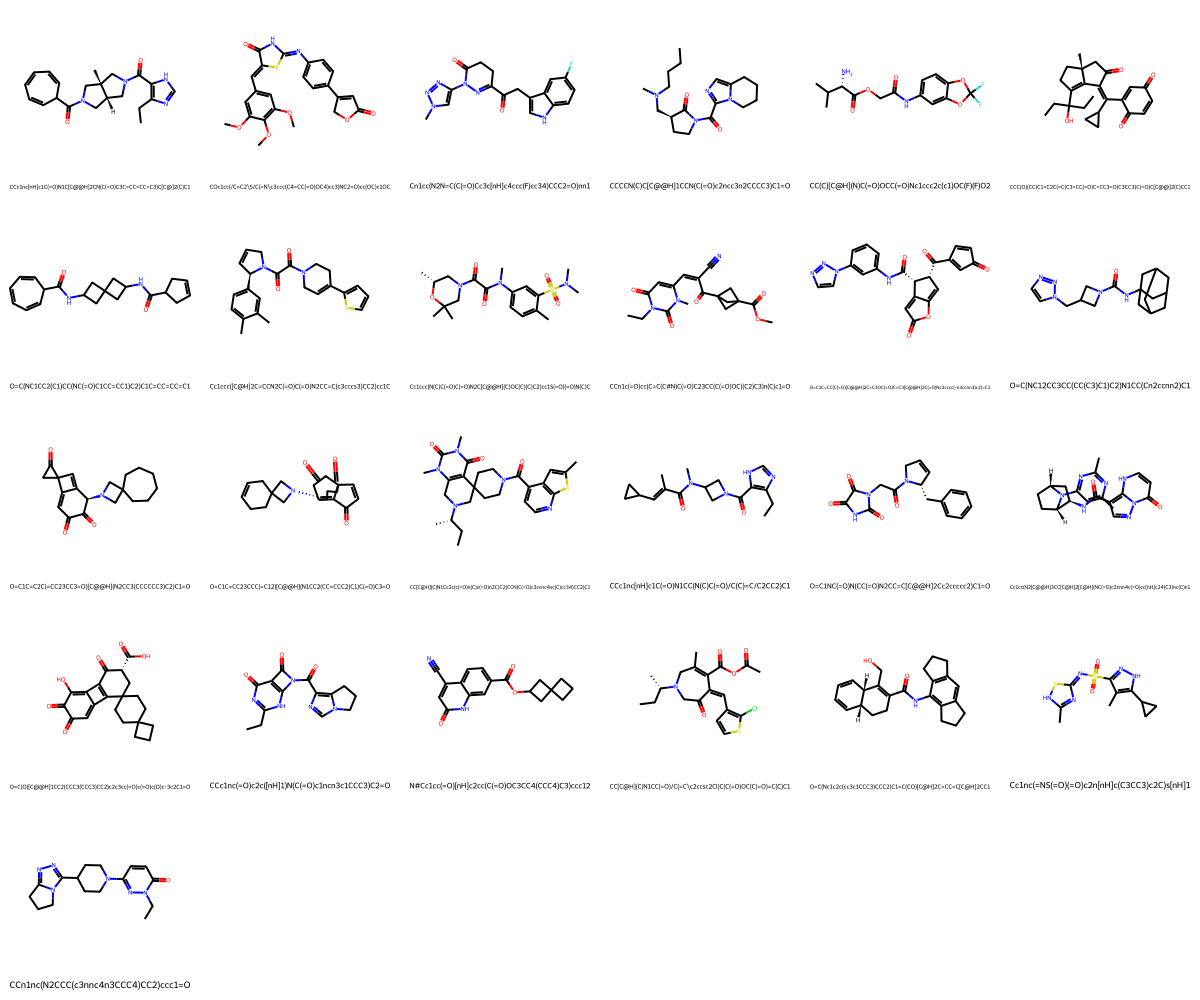

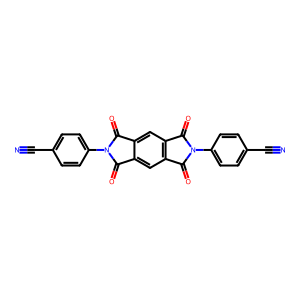

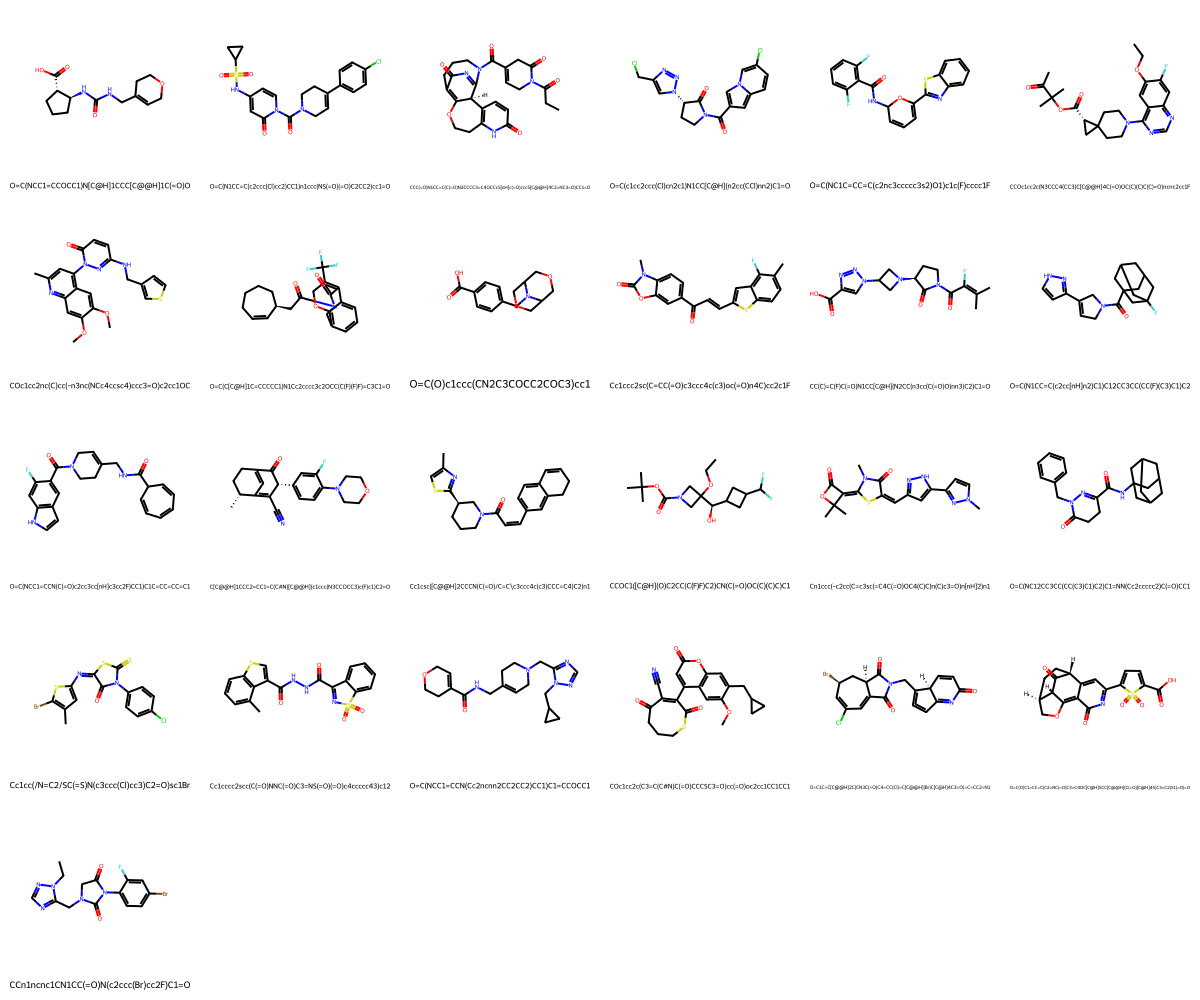

In [17]:
for ori_smis, gen_smis in zip(expert_smiles, gen_smis_lst):
    mol = Chem.MolFromSmiles(ori_smis)
    display(Draw.MolToImage(mol, legends=f"Original {ori_smis}"))
    gen_mols = [Chem.MolFromSmiles(smi) for smi in gen_smis[:25]] # limit the number of molecules to display
    display(Draw.MolsToGridImage(gen_mols, molsPerRow=6, legends=[smi for smi in gen_smis]))
    print("=====================================================================")
    print("\n")